# NLP Project 1 – Hate Speech Classification Pipeline

**Dataset:** [Jigsaw Toxic Comment Classification](https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge/data)  
**Goal:** Systematically compare preprocessing, feature extraction, and models.  
**Principle:** Change one variable at a time, keep the others fixed at baseline.

| ID | What changes | Fixed |
|---|---|---|
| E1 | – (Baseline) | TF-IDF 1000 + SVM |
| E2 | No preprocessing | TF-IDF 1000 + SVM |
| E3 | No stemming | TF-IDF 1000 + SVM |
| E4 | No stopword removal | TF-IDF 1000 + SVM |
| E5 | Bag of Words instead of TF-IDF | Baseline prep + SVM |
| E6 | TF-IDF with 5000 features | Baseline prep + SVM |
| E7 | Logistic Regression | Baseline prep + TF-IDF 1000 |
| E8 | Naive Bayes | Baseline prep + TF-IDF 1000 |

## 0. Setup

In [ ]:
# Install missing packages if needed
# !pip install scikit-learn nltk pandas matplotlib

import nltk
nltk.download('stopwords') # needed to exclude stopwords
nltk.download('wordnet')  # needed for lemmatization

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sarru\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sarru\AppData\Roaming\nltk_data...


True

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# Import our pipeline functions
from pipeline import run_all_experiments, load_and_preprocess, preprocess, get_vectorizer, get_model, run_experiment

print('Setup complete.')

Setup complete.


## 1. Dataset Overview

In [9]:
df_train = pd.read_csv('data/train.csv', encoding='utf-8')
print('Shape:', df_train.shape)
print('\nColumns:', df_train.columns.tolist())
display(df_train.head())

print("\n--- Checking for Missing Values ---")
print(df_train.isnull().sum())

Shape: (159571, 8)

Columns: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0



--- Checking for Missing Values ---
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


Not Hate Speech: 143346 (89.8%)
Hate Speech:     16225 (10.2%)


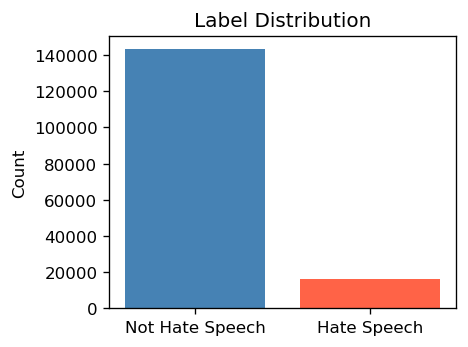

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,binary_label
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,0


In [ ]:
# Label distribution
# add 'binary_label' --> when atleaast one of the below mentioned cols, it will be marked as "hate"
df_train['binary_label'] = df_train[['toxic','severe_toxic','obscene','threat','insult','identity_hate']].max(axis=1)
counts = df_train['binary_label'].value_counts()
print('Not Hate Speech:', counts[0], f'({100*counts[0]/len(df_train):.1f}%)')
print('Hate Speech:    ', counts[1], f'({100*counts[1]/len(df_train):.1f}%)')

# Plot
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(['Not Hate Speech', 'Hate Speech'], [counts[0], counts[1]], color=['steelblue', 'tomato'])
ax.set_title('Label Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
# plt.savefig('fig_label_distribution.png', bbox_inches='tight')
plt.show()

df_train.head()

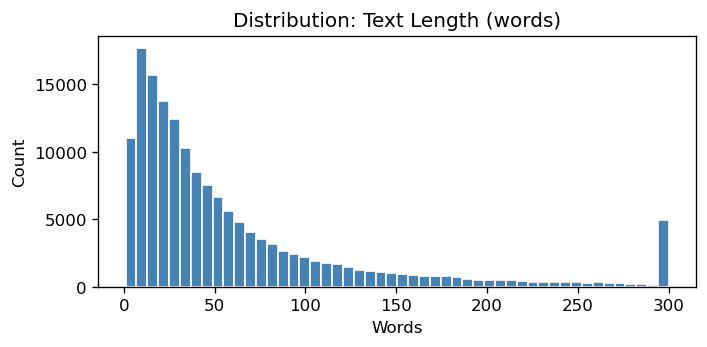

count    159571.0
mean         67.3
std          99.2
min           1.0
25%          17.0
50%          36.0
75%          75.0
max        1411.0
Name: text_len_words, dtype: float64


In [ ]:
# Text length distribution
df_train['text_len_words'] = df_train['comment_text'].str.split().str.len()

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(df_train['text_len_words'].clip(upper=300), bins=50, color='steelblue', edgecolor='white')
ax.set_title('Distribution: Text Length (words)')
ax.set_xlabel('Words')
ax.set_ylabel('Count')
plt.tight_layout()
# plt.savefig('fig_text_length_words.png', bbox_inches='tight')
plt.show()

print(df_train['text_len_words'].describe().round(1))

## 2. Run All Experiments

⚠️ **First run:** Set `reprocess=True` in `load_and_preprocess()` inside `pipeline.py` for each new preprocessing config, or just let it auto-detect missing cache files.  
⏱️ **Runtime:** ~5-15 min total (SVM is the bottleneck)

In [17]:
df_results = run_all_experiments(
    csv_path='data/train.csv',
    downsample=True,   # Use 20% of data for speed - set False for final run
    verbose=False      # Set True to see full classification report per experiment
)

df_results

Processing row 8

Processing row 37


Running E1: Baseline


Processing row 159570


Saved to cache: cache_stem+stop
159571 samples loaded | Label distribution: Counter({0: 143346, 1: 16225})


...

Processing row 50

→ F1 Macro: 0.8212 | F1 Toxic: 0.679

Running E4: Stemming only (no Stopwords)


Processing row 159570


Saved to cache: cache_stem
159571 samples loaded | Label distribution: Counter({0: 143346, 1: 16225})
→ F1 Macro: 0.8376 | F1 Toxic: 0.7071

Running E5: Bag of Words
Using cached data for preprocessing: stem+stop
→ F1 Macro: 0.7819 | F1 Toxic: 0.6176

Running E6: TF-IDF 5000 features
Using cached data for preprocessing: stem+stop
→ F1 Macro: 0.8583 | F1 Toxic: 0.7422

Running E7: Logistic Regression
Using cached data for preprocessing: stem+stop
→ F1 Macro: 0.7795 | F1 Toxic: 0.6174

Running E8: Naive Bayes
Using cached data for preprocessing: stem+stop
→ F1 Macro: 0.7976 | F1 Toxic: 0.6253


,ID,Name,Preprocessing,Vectorizer,Model,F1 Macro,F1 Toxic
0,E1,Baseline,stem+stop,TFIDF (1000),svm,0.8361,0.7051
1,E2,No Preprocessing,none,TFIDF (1000),svm,0.8314,0.6959
2,E3,Stopwords only (no Stemming),stop,TFIDF (1000),svm,0.8212,0.6790
3,E4,Stemming only (no Stopwords),stem,TFIDF (1000),svm,0.8376,0.7071
4,E5,Bag of Words,stem+stop,BOW (1000),svm,0.7819,0.6176
5,E6,TF-IDF 5000 features,stem+stop,TFIDF (5000),svm,0.8583,0.7422
6,E7,Logistic Regression,stem+stop,TFIDF (1000),logreg,0.7795,0.6174
7,E8,Naive Bayes,stem+stop,TFIDF (1000),naivebayes,0.7976,0.6253


## 3. Results

In [18]:
# Save results to CSV
df_results.to_csv('results.csv', index=False)
print('Results saved to results.csv')

# Display sorted by F1 Macro
df_results.sort_values('F1 Macro', ascending=False).style.background_gradient(
    subset=['F1 Macro', 'F1 Toxic'], cmap='RdYlGn'
)

Results saved to results.csv


,ID,Name,Preprocessing,Vectorizer,Model,F1 Macro,F1 Toxic
5,E6,TF-IDF 5000 features,stem+stop,TFIDF (5000),svm,0.858300,0.742200
3,E4,Stemming only (no Stopwords),stem,TFIDF (1000),svm,0.837600,0.707100
0,E1,Baseline,stem+stop,TFIDF (1000),svm,0.836100,0.705100
1,E2,No Preprocessing,none,TFIDF (1000),svm,0.831400,0.695900
2,E3,Stopwords only (no Stemming),stop,TFIDF (1000),svm,0.821200,0.679000
7,E8,Naive Bayes,stem+stop,TFIDF (1000),naivebayes,0.797600,0.625300
4,E5,Bag of Words,stem+stop,BOW (1000),svm,0.781900,0.617600
6,E7,Logistic Regression,stem+stop,TFIDF (1000),logreg,0.779500,0.617400


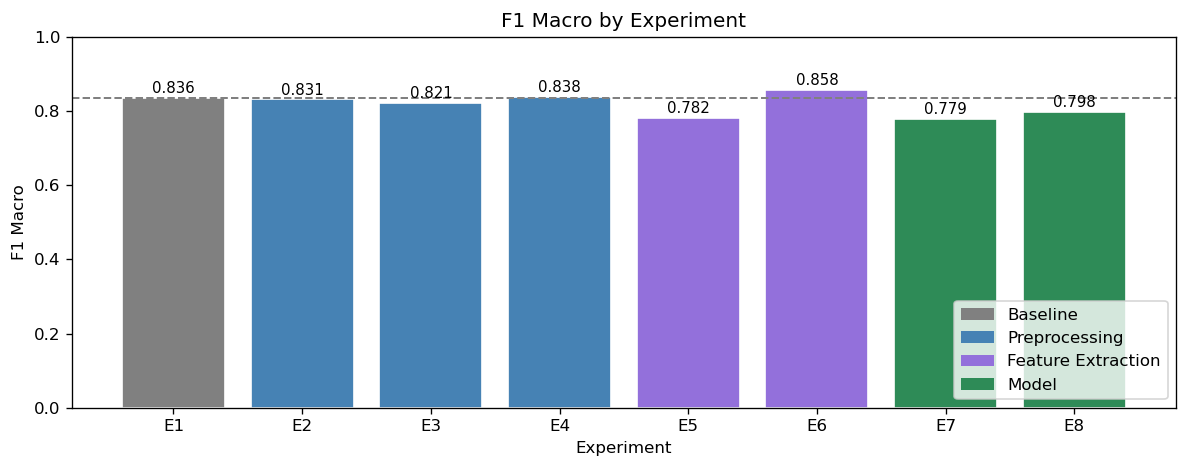

In [19]:
# Bar chart: F1 Macro per experiment
fig, ax = plt.subplots(figsize=(10, 4))

colors = ['gray'] + ['steelblue']*3 + ['mediumpurple']*2 + ['seagreen']*2
bars = ax.bar(df_results['ID'], df_results['F1 Macro'], color=colors, edgecolor='white')

# Baseline line
baseline_f1 = df_results.loc[df_results['ID'] == 'E1', 'F1 Macro'].values[0]
ax.axhline(baseline_f1, color='gray', linestyle='--', linewidth=1.2, label=f'Baseline ({baseline_f1})')

# Value labels
for bar, val in zip(bars, df_results['F1 Macro']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_ylim(0, 1.0)
ax.set_xlabel('Experiment')
ax.set_ylabel('F1 Macro')
ax.set_title('F1 Macro by Experiment')
ax.legend()

# Color legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='gray', label='Baseline'),
    Patch(facecolor='steelblue', label='Preprocessing'),
    Patch(facecolor='mediumpurple', label='Feature Extraction'),
    Patch(facecolor='seagreen', label='Model'),
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
# plt.savefig('fig_results_f1.png', bbox_inches='tight')
plt.show()

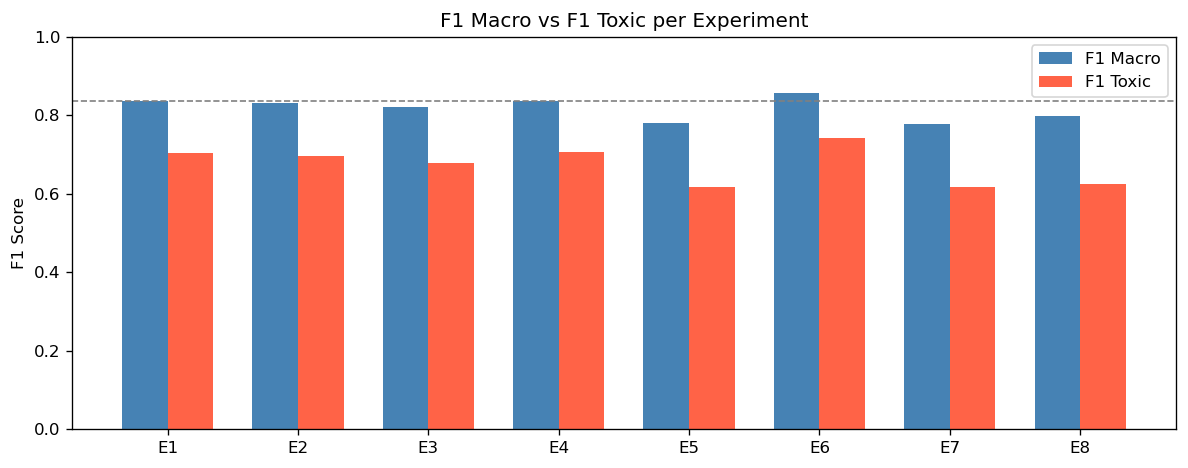

In [20]:
# Grouped comparison: F1 Macro vs F1 Toxic
x = range(len(df_results))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar([i - width/2 for i in x], df_results['F1 Macro'], width, label='F1 Macro', color='steelblue')
ax.bar([i + width/2 for i in x], df_results['F1 Toxic'], width, label='F1 Toxic', color='tomato')

ax.set_xticks(list(x))
ax.set_xticklabels(df_results['ID'])
ax.set_ylim(0, 1.0)
ax.set_ylabel('F1 Score')
ax.set_title('F1 Macro vs F1 Toxic per Experiment')
ax.legend()
ax.axhline(baseline_f1, color='gray', linestyle='--', linewidth=1, label='Baseline F1 Macro')

plt.tight_layout()
# plt.savefig('fig_results_f1_grouped.png', bbox_inches='tight')
plt.show()

## 4. Analysis

Use this section to write your observations for the paper.

In [21]:
# Best experiment overall
best = df_results.loc[df_results['F1 Macro'].idxmax()]
print(f"Best experiment: {best['ID']} – {best['Name']} (F1 Macro: {best['F1 Macro']})")

# Impact per category
baseline_score = df_results.loc[df_results['ID'] == 'E1', 'F1 Macro'].values[0]
print(f"\nBaseline (E1): {baseline_score}")
print("\nDelta vs Baseline:")
for _, row in df_results.iterrows():
    delta = row['F1 Macro'] - baseline_score
    sign = '+' if delta >= 0 else ''
    print(f"  {row['ID']} {row['Name']}: {sign}{delta:.4f}")

Best experiment: E6 – TF-IDF 5000 features (F1 Macro: 0.8583)

Baseline (E1): 0.8361

Delta vs Baseline:
  E1 Baseline: +0.0000
  E2 No Preprocessing: -0.0047
  E3 Stopwords only (no Stemming): -0.0149
  E4 Stemming only (no Stopwords): +0.0015
  E5 Bag of Words: -0.0542
  E6 TF-IDF 5000 features: +0.0222
  E7 Logistic Regression: -0.0566
  E8 Naive Bayes: -0.0385
